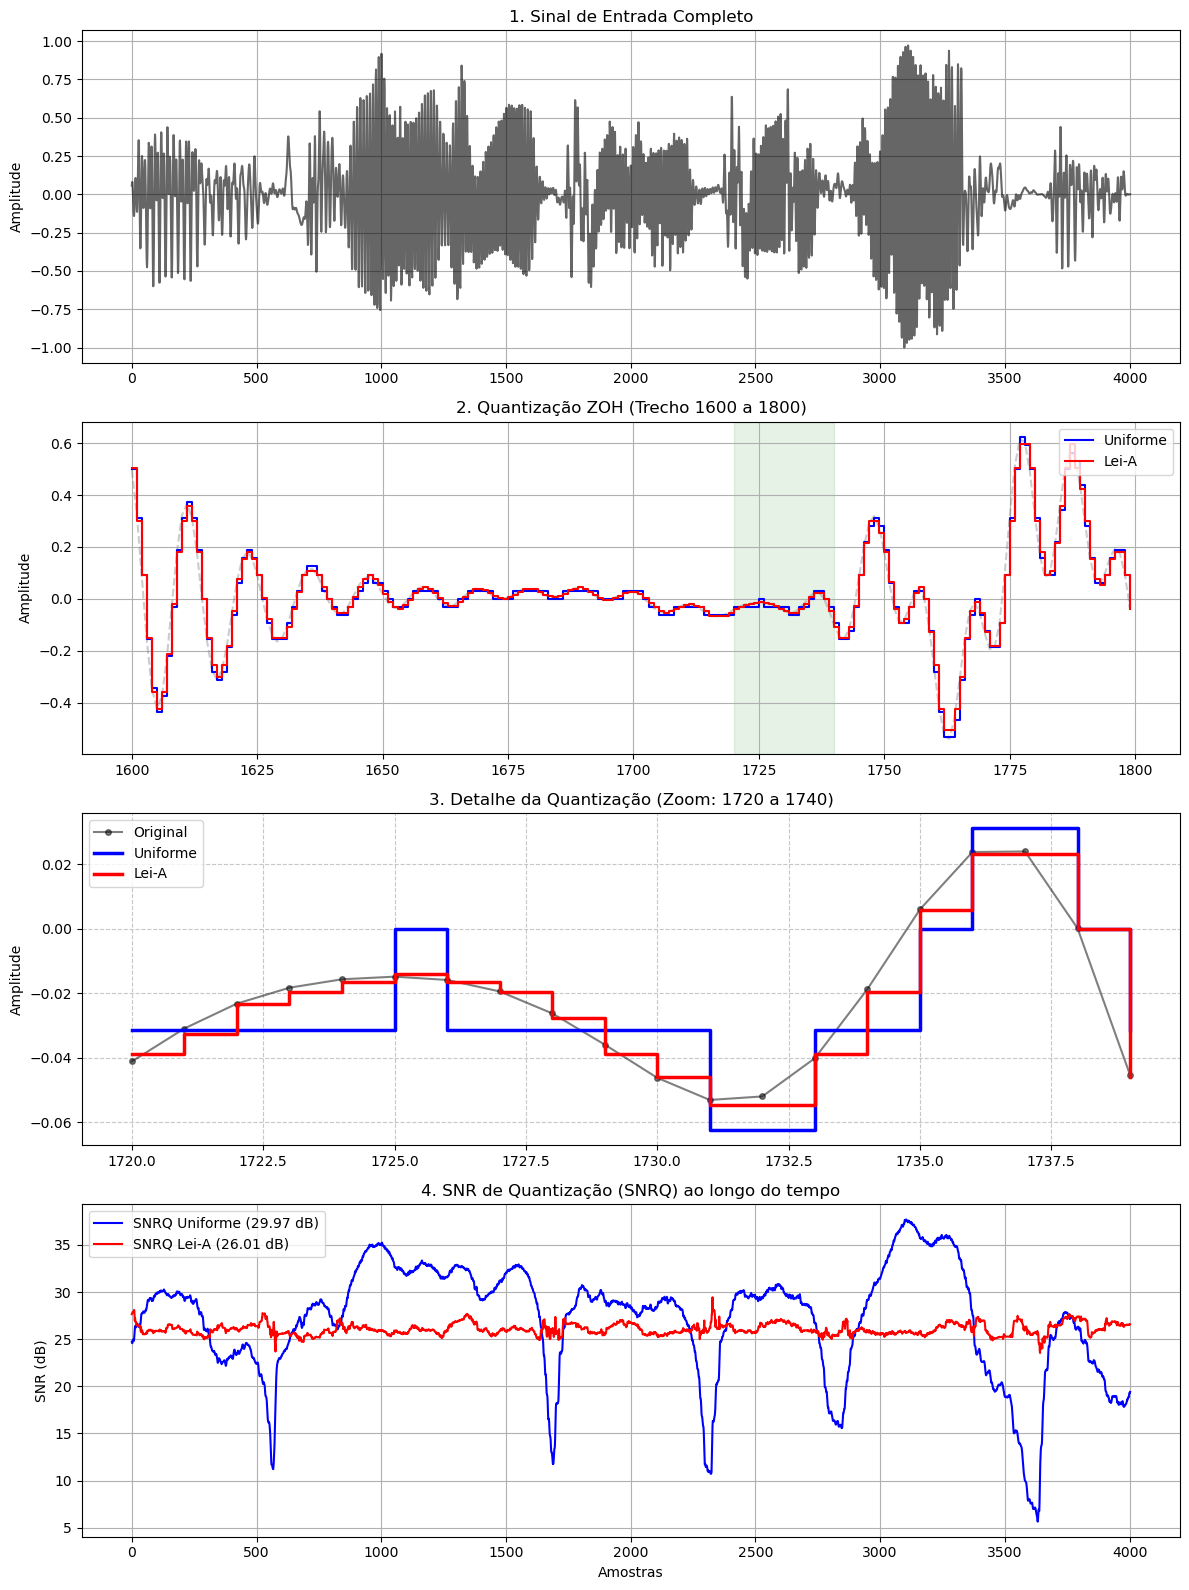

--- Resultados (Quantização 6 bits) ---
Uniforme:     SNR = 29.97 dB
Não-Uniforme: SNR = 26.01 dB


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar os dados do arquivo
def load_data(file_path):
    # O arquivo possui um cabeçalho na primeira linha
    data = np.loadtxt(file_path, skiprows=1)
    return data

# 2. Funções da Lei-A
def a_law_compress(x, A=87.56):
    x_abs = np.abs(x)
    y = np.where(x_abs < 1/A,
                 (A * x_abs) / (1 + np.log(A)),
                 (1 + np.log(A * x_abs)) / (1 + np.log(A)))
    return np.sign(x) * y

def a_law_expand(y, A=87.56):
    y_abs = np.abs(y)
    limit = 1 / (1 + np.log(A))
    x = np.where(y_abs < limit,
                 (y_abs * (1 + np.log(A))) / A,
                 np.exp(y_abs * (1 + np.log(A)) - 1) / A)
    return np.sign(y) * x

# 3. Quantizador Uniforme
def uniform_quantizer(signal, bits):
    levels = 2**bits
    signal_clipped = np.clip(signal, -1, 1)
    step = 2 / levels
    quantized = np.round((signal_clipped + 1) / step) * step - 1
    return np.clip(quantized, -1, 1)

# 4. Cálculo de Métricas (SNR)
def calculate_metrics(original, quantized):
    error = original - quantized
    mse = np.mean(error**2)
    signal_power = np.mean(original**2)
    snr = 10 * np.log10(signal_power / (mse + 1e-10))
    return error, snr

# 5. SNR Temporal (Janela Deslizante)
def running_snr(original, quantized, window_size=100):
    error = original - quantized
    signal_pow = np.convolve(original**2, np.ones(window_size)/window_size, mode='same')
    noise_pow = np.convolve(error**2, np.ones(window_size)/window_size, mode='same')
    return 10 * np.log10(signal_pow / (noise_pow + 1e-10))

# --- Execução Principal ---
A = 87.56
bits = 6
# Ajuste o caminho para o seu ambiente
path = 'C:/Users/luiz.melo/Documents/VoiceFiltered.dat' 
input_signal = load_data(path)

# Normalização
input_signal = input_signal / np.max(np.abs(input_signal))

# A. Quantização Uniforme
quant_uni = uniform_quantizer(input_signal, bits)
_, snr_uni = calculate_metrics(input_signal, quant_uni)

# B. Quantização Não-Uniforme (Lei-A)
compressed = a_law_compress(input_signal, A)
quant_compressed = uniform_quantizer(compressed, bits)
expanded = a_law_expand(quant_compressed, A)
_, snr_non_uni = calculate_metrics(input_signal, expanded)

# --- Plotagem com 4 Subplots ---
t = np.arange(len(input_signal))
fig, axes = plt.subplots(4, 1, figsize=(12, 16))

# Subplot 1: Sinal de Entrada Completo
axes[0].plot(t, input_signal, color='black', alpha=0.6)
axes[0].set_title('1. Sinal de Entrada Completo')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

# Subplot 2: Visão do Trecho (Contexto)
start_ctx, end_ctx = 1600, 1800
axes[1].plot(t[start_ctx:end_ctx], input_signal[start_ctx:end_ctx], color='gray', linestyle='--', alpha=0.4)
axes[1].step(t[start_ctx:end_ctx], quant_uni[start_ctx:end_ctx], where='post', label='Uniforme', color='blue')
axes[1].step(t[start_ctx:end_ctx], expanded[start_ctx:end_ctx], where='post', label='Lei-A', color='red')
axes[1].set_title(f'2. Quantização ZOH (Trecho {start_ctx} a {end_ctx})')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='upper right')
axes[1].grid(True)
# Retângulo verde indicando onde o zoom está olhando
axes[1].axvspan(1720, 1740, color='green', alpha=0.1, label='Área do Zoom')

# Subplot 3: ZOOM ESPECÍFICO (1720 a 1740) - Agora em lugar próprio
start_z, end_z = 1720, 1740
axes[2].plot(t[start_z:end_z], input_signal[start_z:end_z], color='black', marker='o', markersize=4, alpha=0.5, label='Original')
axes[2].step(t[start_z:end_z], quant_uni[start_z:end_z], where='post', color='blue', linewidth=2.5, label='Uniforme')
axes[2].step(t[start_z:end_z], expanded[start_z:end_z], where='post', color='red', linewidth=2.5, label='Lei-A')
axes[2].set_title(f'3. Detalhe da Quantização (Zoom: {start_z} a {end_z})')
axes[2].set_ylabel('Amplitude')
axes[2].legend()
axes[2].grid(True, which='both', linestyle='--', alpha=0.7)

# Subplot 4: SNRQ Temporal
snr_t_uni = running_snr(input_signal, quant_uni)
snr_t_non = running_snr(input_signal, expanded)
axes[3].plot(t, snr_t_uni, label=f'SNRQ Uniforme ({snr_uni:.2f} dB)', color='blue')
axes[3].plot(t, snr_t_non, label=f'SNRQ Lei-A ({snr_non_uni:.2f} dB)', color='red')
axes[3].set_title('4. SNR de Quantização (SNRQ) ao longo do tempo')
axes[3].set_xlabel('Amostras')
axes[3].set_ylabel('SNR (dB)')
axes[3].grid(True)
axes[3].legend()

plt.tight_layout()
plt.show()

print(f"--- Resultados (Quantização {bits} bits) ---")
print(f"Uniforme:     SNR = {snr_uni:.2f} dB")
print(f"Não-Uniforme: SNR = {snr_non_uni:.2f} dB")